# Seminar 6: Factorization Machines & PageRank

## Goals

In this seminar we will:
1. Derive the **Factorization Machine (FM)** model and understand how it generalizes Matrix Factorization to arbitrary feature vectors
2. Implement **FM from scratch** with vectorized mini-batch SGD and **BPR ranking loss** on the **MovieLens 100k** dataset
3. Show that FM with **user and item side features** outperforms pure ID-based MF
4. Compare our scratch FM-BPR against **LightFM-WARP** on the same ranking objective for a fair evaluation
5. Understand the **PageRank** algorithm and implement it via **power iteration**
6. Apply **Personalized PageRank (PPR)** on the **Wikispeedia** Wikipedia article graph to surface related articles
7. Verify our PageRank and PPR implementation against **NetworkX** on the full graph

---
## Part 1: Factorization Machines

## 1. FM formulation

### From Matrix Factorization to Factorization Machines

In standard **Matrix Factorization** we represent each user and item as a latent vector and predict ratings as:

$$\hat{r}_{ui} = \mathbf{u}_u^\top \mathbf{v}_i$$

This only uses user and item IDs. A **Factorization Machine** generalizes this by taking an arbitrary feature vector $\mathbf{x} \in \mathbb{R}^n$ as input. The feature vector can contain:
- One-hot encoded user ID
- One-hot encoded item ID
- User attributes: age, gender, occupation, …
- Item attributes: genres, release year, …
- Context: time of day, device, …

### Model definition

The FM of order 2 predicts:

$$\hat{y}(\mathbf{x}) = w_0 + \sum_{i=1}^{n} w_i x_i + \sum_{i=1}^{n}\sum_{j=i+1}^{n} \langle \mathbf{v}_i, \mathbf{v}_j \rangle\, x_i x_j$$

**Parameters:**
- $w_0 \in \mathbb{R}$: global bias
- $\mathbf{w} \in \mathbb{R}^n$: linear weights (one per feature)
- $\mathbf{V} \in \mathbb{R}^{k \times n}$: factor matrix — each feature $i$ gets a latent vector $\mathbf{v}_i \in \mathbb{R}^k$

The interaction term $\langle \mathbf{v}_i, \mathbf{v}_j \rangle x_i x_j$ models the pairwise interaction between features $i$ and $j$ via their inner product. When $\mathbf{x}$ contains only user and item one-hots, this term recovers the standard MF dot product.

---

### Efficient computation — $O(kn)$ instead of $O(kn^2)$

Naively computing all $\binom{n}{2}$ pairwise interactions costs $O(kn^2)$. The key identity reduces this to $O(kn)$:

$$\sum_{i=1}^{n}\sum_{j=i+1}^{n} \langle \mathbf{v}_i, \mathbf{v}_j \rangle x_i x_j
= \frac{1}{2}\sum_{f=1}^{k}\left[\left(\sum_{i=1}^{n} v_{if}\, x_i\right)^2 - \sum_{i=1}^{n} v_{if}^2\, x_i^2\right]$$

**Why the two terms look different:**
- **First term** $\left(\sum_i v_{if} x_i\right)^2$: the inner sum produces a single number (a dot product), which is then *squared*. Summing over $f$ gives $\|\mathbf{V}\mathbf{x}\|_2^2$ — a squared L2 norm.
- **Second term** $\sum_i v_{if}^2 x_i^2$: the products $v_{if}^2 x_i^2$ are summed directly, *without* any outer squaring. Summing over $f$ gives $\mathbf{1}_k^\top (\mathbf{V} \odot \mathbf{V})(\mathbf{x} \odot \mathbf{x})$ — just a sum, not a norm.

In matrix notation for a **batch** $X \in \mathbb{R}^{B \times n}$ (both terms are $B \times k$ matrices, then summed over $k$ via $\mathbf{1}_k$):

$$\text{interaction}(X) = \frac{1}{2}\Bigl[\underbrace{(X\mathbf{V}^\top)^{\odot 2}}_{\text{element-wise square}} - \underbrace{X_{\odot 2}\,(\mathbf{V} \odot \mathbf{V})^\top}_{\text{no extra squaring}}\Bigr]\,\mathbf{1}_k$$

For sparse $\mathbf{x}$ with $|\mathbf{x}|$ non-zero entries the cost is $O(k|\mathbf{x}|)$.

---

### Vectorised gradient scaffold

Regardless of the loss, every SGD update reduces to the same three sparse–dense products. Given a vector of **effective errors** $\mathbf{e} \in \mathbb{R}^B$ and the cached $\mathbf{Vx} = X\mathbf{V}^\top \in \mathbb{R}^{B \times k}$:

$$\nabla_{w_0} = \frac{1}{B}\sum_s e_s, \qquad
\nabla_{\mathbf{w}} = \frac{1}{B} X^\top \mathbf{e} + 2\lambda_w \mathbf{w}$$

$$\nabla_{\mathbf{V}^\top} = \frac{1}{B}\left[X^\top(\mathbf{e} \odot \mathbf{Vx}) - (X_{\odot 2}^\top \mathbf{e}) \odot \mathbf{V}^\top\right] + 2\lambda_V\mathbf{V}^\top$$

**For MSE** — $e_s = 2(\hat{y}_s - y_s)$ (used in the sanity check)

**For BPR** — $e^\text{pos}_s = \sigma_s - 1,\; e^\text{neg}_s = 1 - \sigma_s$ where $\sigma_s = \sigma(\hat{y}_\text{pos} - \hat{y}_\text{neg})$ (used in the main training — see Section 5)

## 2. Dataset: MovieLens 100k

We use the **MovieLens 100k** dataset from GroupLens:
- 100,000 ratings on a 1–5 scale
- 943 users and 1,682 movies
- Each user has rated at least 20 movies

What makes this dataset ideal for FM is the **rich side information**:

| File | Content |
|---|---|
| `u.data` | `user_id`, `item_id`, `rating`, `timestamp` |
| `u.user` | `user_id`, `age`, `gender`, `occupation`, `zip` |
| `u.item` | `item_id`, `title`, `release_year`, 19 binary genre columns |

We will build a sparse feature vector $\mathbf{x}$ for each (user, item) pair that stacks:
- One-hot user ID (943 dims)
- User age bucket, gender, occupation (one-hot, ~25 dims total)
- One-hot item ID (1,682 dims)
- Item genres (19 binary dims)

This turns each rating sample into a sparse vector of ~2,670 features.

Dataset page: https://grouplens.org/datasets/movielens/100k/

In [92]:
!pip install lightfm tqdm --quiet

In [93]:
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

plt.style.use("ggplot")

In [94]:
DATA_DIR = Path("ml-100k")
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

if not DATA_DIR.exists():
    print("Downloading MovieLens 100k...")
    zip_path = Path("ml-100k.zip")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print("Done.")

# Ratings
ratings = pd.read_csv(
    DATA_DIR / "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

# User features: user_id | age | gender | occupation | zip
users = pd.read_csv(
    DATA_DIR / "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip"],
)

# Item features: item_id | title | release_date | video_date | url | 19 genre flags
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
item_cols = ["item_id", "title", "release_date", "video_date", "url"] + genre_cols
items = pd.read_csv(
    DATA_DIR / "u.item",
    sep="|",
    names=item_cols,
    encoding="latin-1",
)

print(f"Ratings : {len(ratings):,}")
print(f"Users   : {ratings['user_id'].nunique():,}")
print(f"Items   : {ratings['item_id'].nunique():,}")
ratings.head()

Ratings : 100,000
Users   : 943
Items   : 1,682


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [97]:
items.head(10)

,item_id,title,release_date,video_date,url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,01-Jan-1995,NaN,http://us.imdb.com/Title?Yao+a+yao+yao+dao+wai...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,Twelve Monkeys (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Twelve%20Monk...,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7,8,Babe (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Babe%20(1995),0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,9,Dead Man Walking (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Dead%20Man%20...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,10,Richard III (1995),22-Jan-1996,NaN,http://us.imdb.com/M/title-exact?Richard%20III...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


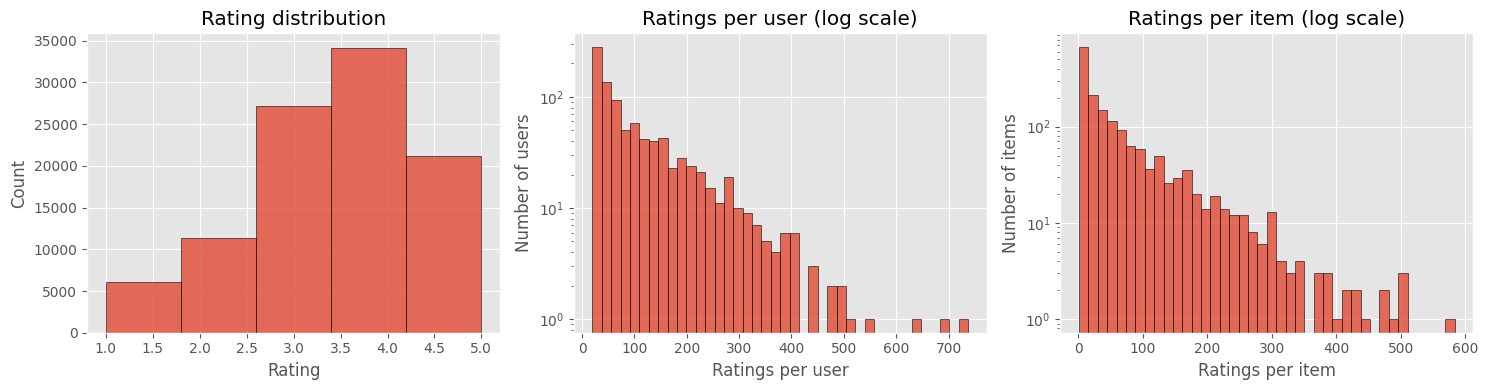

Matrix sparsity: 93.70%


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
axes[0].hist(ratings["rating"], bins=5, edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating distribution")

# Ratings per user
user_counts = ratings.groupby("user_id").size()
axes[1].hist(user_counts, bins=40, edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Ratings per user")
axes[1].set_ylabel("Number of users")
axes[1].set_yscale("log")
axes[1].set_title("Ratings per user (log scale)")

# Ratings per item
item_counts = ratings.groupby("item_id").size()
axes[2].hist(item_counts, bins=40, edgecolor="black", alpha=0.8)
axes[2].set_xlabel("Ratings per item")
axes[2].set_ylabel("Number of items")
axes[2].set_yscale("log")
axes[2].set_title("Ratings per item (log scale)")

plt.tight_layout()
plt.show()

n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
sparsity = 1 - len(ratings) / (n_users * n_items)
print(f"Matrix sparsity: {sparsity*100:.2f}%")

## 3. Feature matrix construction

For each rating $(u, i, r)$ we build a sparse feature vector $\mathbf{x}$ by horizontally stacking four blocks:

```
[ one-hot(user_id) | user_age_bin, gender, occupation | one-hot(item_id) | item_genres ]
      943 dims              ~25 dims                        1682 dims          19 dims
```

We use `scipy.sparse` throughout — the resulting matrix has ~2,670 columns but only ~25 non-zeros per row.

In [98]:
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, OneHotEncoder

# ── compact integer indices ──────────────────────────────────────────────────
user_enc = LabelEncoder().fit(ratings["user_id"])
item_enc = LabelEncoder().fit(ratings["item_id"])

df = ratings.copy()
df["user_idx"] = user_enc.transform(df["user_id"])
df["item_idx"] = item_enc.transform(df["item_id"])

N = len(df)
n_users = len(user_enc.classes_)   # 943
n_items = len(item_enc.classes_)   # 1682

# ── Block 1: one-hot user ID ─────────────────────────────────────────────────
rows = np.arange(N)
block_user = sparse.csr_matrix(
    (np.ones(N), (rows, df["user_idx"].to_numpy())),
    shape=(N, n_users),
    dtype=np.float32,
)

# ── Block 2: user side features (age bucket + gender + occupation) ───────────
users_idx = users.copy()
users_idx["user_idx"] = user_enc.transform(users_idx["user_id"])
users_idx = users_idx.set_index("user_idx").reindex(range(n_users))

# age → 7 equal-width bins
age_binner = KBinsDiscretizer(n_bins=7, encode="onehot-dense", strategy="uniform")
age_ohe = age_binner.fit_transform(users_idx["age"].fillna(0).to_numpy().reshape(-1, 1))

# gender → binary (M=1, F=0)
gender_bin = (users_idx["gender"].fillna("M") == "M").to_numpy().astype(np.float32).reshape(-1, 1)

# occupation → one-hot
occ_ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore").fit_transform(
    users_idx["occupation"].fillna("other").to_numpy().reshape(-1, 1)
)

# stack and select rows for our samples
user_side = sparse.hstack(
    [sparse.csr_matrix(age_ohe), sparse.csr_matrix(gender_bin), occ_ohe],
    format="csr",
    dtype=np.float32,
)
block_user_side = user_side[df["user_idx"].to_numpy()]

# ── Block 3: one-hot item ID ─────────────────────────────────────────────────
block_item = sparse.csr_matrix(
    (np.ones(N), (rows, df["item_idx"].to_numpy())),
    shape=(N, n_items),
    dtype=np.float32,
)

# ── Block 4: item genres (19 binary flags) ───────────────────────────────────
items_idx = items.copy()
items_idx["item_idx"] = item_enc.transform(items_idx["item_id"])
items_idx = items_idx.set_index("item_idx").reindex(range(n_items))

genre_matrix = sparse.csr_matrix(
    items_idx[genre_cols].fillna(0).to_numpy().astype(np.float32)
)
block_item_side = genre_matrix[df["item_idx"].to_numpy()]

# ── Stack all blocks ─────────────────────────────────────────────────────────
X_full = sparse.hstack(
    [block_user, block_user_side, block_item, block_item_side],
    format="csr",
    dtype=np.float32,
)
y = df["rating"].to_numpy(dtype=np.float32)

print(f"Feature matrix : {X_full.shape}  (samples × features)")
print(f"Non-zeros/row  : {X_full.nnz / X_full.shape[0]:.1f}")
print(f"Target y       : min={y.min()}, max={y.max()}, mean={y.mean():.2f}")

Feature matrix : (100000, 2673)  (samples × features)
Non-zeros/row  : 6.9
Target y       : min=1.0, max=5.0, mean=3.53


## 4. Train / test split

We use a **chronological split**: sort all ratings by timestamp and put the last 20% into the test set. This simulates a real deployment scenario where the model is trained on historical data and evaluated on future interactions.

In [99]:
# Chronological split: last 20% of ratings (sorted by timestamp) go to test
order = df["timestamp"].argsort().to_numpy()
split = int(0.8 * len(order))

train_idx = order[:split]
test_idx  = order[split:]

X_train, y_train = X_full[train_idx], y[train_idx]
X_test,  y_test  = X_full[test_idx],  y[test_idx]

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,}  samples")

# Also keep track of (user_idx, item_idx) for ranking evaluation later
train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

Train : 80,000 samples
Test  : 20,000  samples


## 5. FM implementation with BPR loss

We train with **Bayesian Personalized Ranking (BPR)** — the same objective as LightFM-WARP — so both models are evaluated on equal footing.

BPR maximises the probability that a user prefers observed item $i$ over an unobserved item $j$:

$$\mathcal{L}_\text{BPR} = -\frac{1}{B}\sum_{(u,i,j)} \log \sigma\!\left(\hat{y}(u,i) - \hat{y}(u,j)\right) + \text{regularisation}$$

where $j$ is a **uniformly sampled negative** item not (necessarily) in the user's history.

The gradient w.r.t. any parameter $\theta$ uses the chain rule through $\sigma$:

$$\frac{\partial \mathcal{L}}{\partial \theta} = -\frac{1}{B}\sum_b \underbrace{(1 - \sigma_b)}_{\text{error weight}} \left(\frac{\partial \hat{y}_\text{pos}}{\partial \theta} - \frac{\partial \hat{y}_\text{neg}}{\partial \theta}\right)$$

Setting $e_\text{pos} = \sigma - 1$ and $e_\text{neg} = 1 - \sigma$, this is exactly the same expression as the MSE gradient — we reuse the vectorised update from Section 1 with different "effective errors".

The same two sparse–dense products dominate the computation per batch:
```
Vx_pos = X_pos @ V.T    Vx_neg = X_neg @ V.T
```

In [100]:
class FactorizationMachine:
    """
    Factorization Machine supporting two losses:

    MSE  — rating prediction, fit(X, y) where X is a sparse feature matrix
    BPR  — ranking loss,      fit_bpr(user_idx, item_idx, ...) with negative sampling

    BPR gradient for a triplet (u, pos, neg):
        e_pos = σ(ŷ_pos − ŷ_neg) − 1      → push ŷ_pos up
        e_neg = 1 − σ(ŷ_pos − ŷ_neg)      → push ŷ_neg down
    Then reuse the same vectorised update as MSE with these effective errors.
    """

    def __init__(
        self,
        n_factors: int = 16,
        n_epochs: int = 20,
        lr: float = 0.01,
        reg_w: float = 0.01,
        reg_v: float = 0.01,
        batch_size: int = 512,
        random_state: int = 42,
    ):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg_w = reg_w
        self.reg_v = reg_v
        self.batch_size = batch_size
        self.random_state = random_state

    # ── parameter initialisation ─────────────────────────────────────────────
    def _init_params(self, n_features: int) -> None:
        rng = np.random.default_rng(self.random_state)
        self.w0_: float = 0.0
        self.w_: np.ndarray = np.zeros(n_features, dtype=np.float32)
        self.V_: np.ndarray = (
            0.01 * rng.standard_normal((self.n_factors, n_features))
        ).astype(np.float32)

    # ── forward pass (batch) ─────────────────────────────────────────────────
    def _forward(self, X: sparse.csr_matrix):
        X_sq = X.copy()
        X_sq.data **= 2
        linear = np.asarray(X @ self.w_).ravel()
        Vx     = np.asarray(X @ self.V_.T, dtype=np.float32)
        V2x2   = np.asarray(X_sq @ (self.V_ ** 2).T, dtype=np.float32)
        interaction = 0.5 * np.sum(Vx ** 2 - V2x2, axis=1)
        return self.w0_ + linear + interaction, Vx, X_sq

    # ── vectorised parameter update given effective errors ───────────────────
    def _apply_gradients(self, X, errors, Vx, X_sq):
        B = X.shape[0]
        e = errors.astype(np.float32)
        self.w0_ -= self.lr * e.sum() / B
        grad_w = np.asarray(X.T @ e).ravel() / B
        self.w_ -= self.lr * (grad_w + 2 * self.reg_w * self.w_)
        term1   = X.T @ (e[:, None] * Vx)
        term2   = np.asarray(X_sq.T @ e).ravel()
        grad_VT = (np.asarray(term1, dtype=np.float32) - term2[:, None] * self.V_.T) / B
        self.V_ -= self.lr * (grad_VT.T + 2 * self.reg_v * self.V_)

    # ── MSE step ─────────────────────────────────────────────────────────────
    def _step_mse(self, X, y):
        y_hat, Vx, X_sq = self._forward(X)
        e = (y_hat - y).astype(np.float32)
        self._apply_gradients(X, 2 * e, Vx, X_sq)
        return float(np.mean(e ** 2))

    # ── BPR step ─────────────────────────────────────────────────────────────
    def _step_bpr(self, X_pos, X_neg):
        y_pos, Vx_pos, Xsq_pos = self._forward(X_pos)
        y_neg, Vx_neg, Xsq_neg = self._forward(X_neg)

        sigma = 1.0 / (1.0 + np.exp(-np.clip(y_pos - y_neg, -30, 30)))
        e_pos = (sigma - 1.0).astype(np.float32)
        e_neg = (1.0 - sigma).astype(np.float32)
        B = X_pos.shape[0]

        self.w0_ -= self.lr * (e_pos.sum() + e_neg.sum()) / B

        grad_w = (np.asarray(X_pos.T @ e_pos).ravel() +
                  np.asarray(X_neg.T @ e_neg).ravel()) / B
        self.w_ -= self.lr * (grad_w + 2 * self.reg_w * self.w_)

        term1 = (X_pos.T @ (e_pos[:, None] * Vx_pos) +
                 X_neg.T @ (e_neg[:, None] * Vx_neg))
        term2 = (np.asarray(Xsq_pos.T @ e_pos).ravel() +
                 np.asarray(Xsq_neg.T @ e_neg).ravel())
        grad_VT = (np.asarray(term1, dtype=np.float32) - term2[:, None] * self.V_.T) / B
        self.V_ -= self.lr * (grad_VT.T + 2 * self.reg_v * self.V_)

        return -float(np.mean(np.log(sigma + 1e-9)))

    # ── build feature matrix for arbitrary (user, item) index pairs ──────────
    def _build_X(self, user_indices, item_indices):
        B = len(user_indices)
        rows = np.arange(B)
        u_block = sparse.csr_matrix(
            (np.ones(B, dtype=np.float32), (rows, user_indices)),
            shape=(B, self._n_users), dtype=np.float32,
        )
        i_block = sparse.csr_matrix(
            (np.ones(B, dtype=np.float32), (rows, item_indices)),
            shape=(B, self._n_items), dtype=np.float32,
        )
        return sparse.hstack(
            [u_block, self._user_side[user_indices],
             i_block, self._item_side[item_indices]],
            format="csr", dtype=np.float32,
        )

    # ── MSE training ─────────────────────────────────────────────────────────
    def fit(self, X: sparse.csr_matrix, y: np.ndarray):
        """Train with MSE loss. X: sparse (N, n_features), y: ratings."""
        X = sparse.csr_matrix(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        self._init_params(X.shape[1])
        rng = np.random.default_rng(self.random_state)
        self.train_rmse_: list[float] = []

        epoch_bar = tqdm(range(self.n_epochs), desc="Training (MSE)", unit="epoch")
        for _ in epoch_bar:
            order  = rng.permutation(X.shape[0])
            losses = []
            for start in range(0, X.shape[0], self.batch_size):
                idx = order[start: start + self.batch_size]
                losses.append(self._step_mse(X[idx], y[idx]))
            rmse = float(np.sqrt(np.mean(losses)))
            self.train_rmse_.append(rmse)
            epoch_bar.set_postfix({"RMSE": f"{rmse:.4f}"})

        return self

    # ── BPR training ─────────────────────────────────────────────────────────
    def fit_bpr(self, user_indices, item_indices,
                n_users, n_items, user_side_feat, item_side_feat):
        """
        Train with BPR loss.

        user_indices, item_indices : arrays of positive (u, i) pairs
        user_side_feat             : sparse (n_users, d_u)
        item_side_feat             : sparse (n_items, d_i)
        """
        self._n_users   = n_users
        self._n_items   = n_items
        self._user_side = sparse.csr_matrix(user_side_feat, dtype=np.float32)
        self._item_side = sparse.csr_matrix(item_side_feat, dtype=np.float32)

        n_features = n_users + self._user_side.shape[1] + n_items + self._item_side.shape[1]
        self._init_params(n_features)

        user_indices = np.asarray(user_indices, dtype=np.int32)
        item_indices = np.asarray(item_indices, dtype=np.int32)
        n_samples    = len(user_indices)

        rng = np.random.default_rng(self.random_state)
        self.train_bpr_loss_: list[float] = []

        epoch_bar = tqdm(range(self.n_epochs), desc="Training (BPR)", unit="epoch")
        for _ in epoch_bar:
            order  = rng.permutation(n_samples)
            losses = []
            for start in range(0, n_samples, self.batch_size):
                idx     = order[start: start + self.batch_size]
                u_batch = user_indices[idx]
                i_batch = item_indices[idx]
                j_batch = rng.integers(0, n_items, size=len(idx), dtype=np.int32)
                X_pos   = self._build_X(u_batch, i_batch)
                X_neg   = self._build_X(u_batch, j_batch)
                losses.append(self._step_bpr(X_pos, X_neg))

            avg = float(np.mean(losses))
            self.train_bpr_loss_.append(avg)
            epoch_bar.set_postfix({"BPR loss": f"{avg:.4f}"})

        return self

    # ── inference ────────────────────────────────────────────────────────────
    def predict(self, X: sparse.csr_matrix) -> np.ndarray:
        y_hat, _, _ = self._forward(sparse.csr_matrix(X, dtype=np.float32))
        return y_hat

    def predict_user(self, user_idx: int) -> np.ndarray:
        """Score all items for a given user (requires fit_bpr)."""
        u_arr = np.full(self._n_items, user_idx, dtype=np.int32)
        i_arr = np.arange(self._n_items, dtype=np.int32)
        return self.predict(self._build_X(u_arr, i_arr))

### Sanity check

Before training on real data we verify three things on a small synthetic example:
1. Output shape is correct
2. Loss decreases with training
3. FM with $k=0$ (no interactions, only linear terms) recovers a linear regression

In [101]:
rng = np.random.default_rng(0)

# Small synthetic sparse dataset
n_syn, d_syn = 200, 50
X_syn = sparse.random(n_syn, d_syn, density=0.1, format="csr",
                      data_rvs=rng.standard_normal).astype(np.float32)
# True signal: linear + one pairwise interaction
w_true = rng.standard_normal(d_syn).astype(np.float32)
y_syn  = np.asarray(X_syn @ w_true).ravel() + rng.standard_normal(n_syn).astype(np.float32) * 0.1

# 1. Shape check
fm_tiny = FactorizationMachine(n_factors=4, n_epochs=1, batch_size=50, random_state=0)
fm_tiny.fit(X_syn, y_syn)
preds = fm_tiny.predict(X_syn)
assert preds.shape == (n_syn,), "predict() shape mismatch"
print(f"Shape check passed: predict() → {preds.shape}")

# 2. Loss decreases
fm_check = FactorizationMachine(n_factors=8, n_epochs=10, lr=0.05,
                                batch_size=50, random_state=0)
fm_check.fit(X_syn, y_syn)
assert fm_check.train_rmse_[-1] < fm_check.train_rmse_[0], "RMSE did not decrease"
print(f"Loss check passed: RMSE {fm_check.train_rmse_[0]:.4f} → {fm_check.train_rmse_[-1]:.4f}")

# 3. Zero factors → pure linear regression
fm_linear = FactorizationMachine(n_factors=0, n_epochs=20, lr=0.05,
                                 batch_size=50, reg_w=0.0, random_state=0)
fm_linear.fit(X_syn, y_syn)
rmse_lin = np.sqrt(np.mean((fm_linear.predict(X_syn) - y_syn) ** 2))
print(f"Linear-only RMSE on train: {rmse_lin:.4f}  (should be close to noise level ~0.1)")

Training (MSE):   0%|          | 0/1 [00:00<?, ?epoch/s]

Shape check passed: predict() → (200,)


Training (MSE):   0%|          | 0/10 [00:00<?, ?epoch/s]

Loss check passed: RMSE 1.9040 → 1.2677


Training (MSE):   0%|          | 0/20 [00:00<?, ?epoch/s]

Linear-only RMSE on train: 0.8236  (should be close to noise level ~0.1)


## 6. Training on MovieLens 100k

Both models use the **same BPR objective**, the same features, and the same 20 epochs, so the comparison is direct.

| Model | Loss | Features |
|---|---|---|
| **FM-BPR (scratch)** | BPR | one-hot IDs + age/gender/occupation + genres |
| **LightFM-WARP** | WARP ≈ BPR | occupation (user) + genres (item) |

We treat all rated items as positive interactions (implicit feedback convention).

In [120]:
# Positive (user, item) pairs from training data
train_users = train_df["user_idx"].to_numpy(dtype=np.int32)
train_items = train_df["item_idx"].to_numpy(dtype=np.int32)

# user_side and genre_matrix were built in Section 3
# user_side  : (n_users, d_user_side)  sparse
# genre_matrix: (n_items, 19)          sparse

fm_bpr = FactorizationMachine(
    n_factors=16, n_epochs=100, lr=0.05,
    reg_w=0.001, reg_v=0.001, batch_size=512, random_state=42,
)
fm_bpr.fit_bpr(
    train_users, train_items,
    n_users=n_users, n_items=n_items,
    user_side_feat=user_side,
    item_side_feat=genre_matrix,
)

Training (BPR):   0%|          | 0/100 [00:00<?, ?epoch/s]

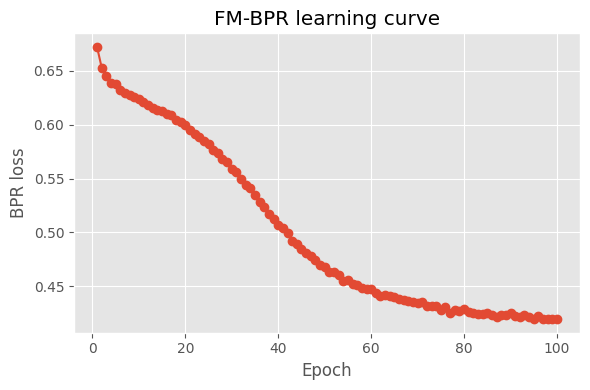

In [121]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, fm_bpr.n_epochs + 1), fm_bpr.train_bpr_loss_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR loss")
plt.title("FM-BPR learning curve")
plt.tight_layout()
plt.show()

## 7. Comparison with LightFM

Both models now use a BPR-style ranking loss, so the evaluation is a direct apples-to-apples comparison on **HitRate@10** and **NDCG@10** (leave-last-out).

The remaining differences are:
- Our FM uses a richer feature set (one-hot IDs + side features)
- LightFM-WARP uses a slightly different loss (WARP samples negatives until a violation is found, making hard negatives more likely)
- LightFM is implemented in C and optimised for speed

In [118]:
from lightfm import LightFM
from lightfm.data import Dataset as LFMDataset

# ── build LightFM dataset ────────────────────────────────────────────────────
lfm_dataset = LFMDataset()
lfm_dataset.fit(
    users=ratings["user_id"].unique(),
    items=ratings["item_id"].unique(),
    user_features=users["occupation"].unique(),
    item_features=genre_cols,
)

# interactions from train ratings
train_interactions, _ = lfm_dataset.build_interactions(
    (row.user_id, row.item_id) for _, row in train_df.iterrows()
)

# user feature matrix: occupation
user_feat_list = [
    (row.user_id, [row.occupation]) for _, row in users.iterrows()
]
lfm_user_features = lfm_dataset.build_user_features(user_feat_list)

# item feature matrix: genres
item_feat_list = [
    (row.item_id, [g for g in genre_cols if row[g] == 1])
    for _, row in items.iterrows()
]
lfm_item_features = lfm_dataset.build_item_features(item_feat_list)

# ── train LightFM WARP ───────────────────────────────────────────────────────
lfm_model = LightFM(no_components=16, loss="warp", random_state=42)
lfm_model.fit(
    train_interactions,
    user_features=lfm_user_features,
    item_features=lfm_item_features,
    epochs=100,
    num_threads=4,
    verbose=True,
)
print("LightFM training done.")

Epoch: 100%|██████████| 100/100 [00:07<00:00, 14.22it/s]

LightFM training done.


Evaluating FM-BPR ...
Evaluating LightFM-WARP ...

            Model  HitRate@10  NDCG@10
FM-BPR (scratch)    0.059801  0.02403
    LightFM-WARP    0.073090  0.03585


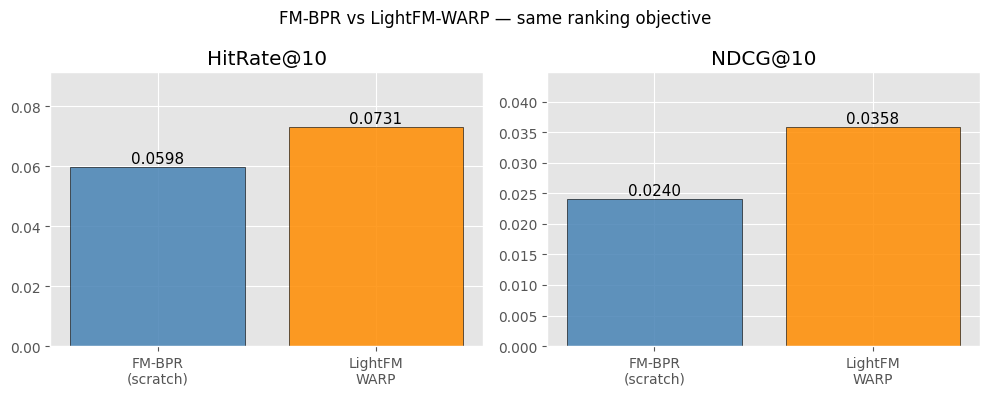

In [122]:
K = 10

# ── leave-last-out ground truth ───────────────────────────────────────────────
heldout = (
    test_df.sort_values("timestamp")
    .groupby("user_idx")["item_idx"]
    .last()
    .to_dict()
)
train_seen = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()

# ── ranking metrics ───────────────────────────────────────────────────────────
def hitrate_ndcg(score_fn, heldout, train_seen, k=10):
    hits, ndcg_sum, total = 0, 0.0, 0
    for u, true_item in heldout.items():
        scores = score_fn(u).copy()
        scores[list(train_seen.get(u, set()))] = -np.inf
        top_k = np.argpartition(-scores, k)[:k]
        top_k = top_k[np.argsort(-scores[top_k])]
        if true_item in top_k:
            hits += 1
            rank = int(np.where(top_k == true_item)[0][0]) + 1
            ndcg_sum += 1.0 / np.log2(rank + 1)
        total += 1
    return hits / total, ndcg_sum / total

# ── FM-BPR score function ─────────────────────────────────────────────────────
def fm_bpr_score(u):
    return fm_bpr.predict_user(u)

# ── LightFM score function ────────────────────────────────────────────────────
lfm_uid_map, _, lfm_iid_map, _ = lfm_dataset.mapping()
user_id_arr = user_enc.classes_
lfm_iid_rev = {v: item_enc.transform([k])[0]
               for k, v in lfm_iid_map.items() if k in item_enc.classes_}

def lfm_score(u):
    raw_uid = int(user_id_arr[u])
    lfm_u   = lfm_uid_map.get(raw_uid)
    if lfm_u is None:
        return np.zeros(n_items)
    scores_raw = lfm_model.predict(
        user_ids=lfm_u,
        item_ids=np.arange(train_interactions.shape[1]),
        user_features=lfm_user_features,
        item_features=lfm_item_features,
    )
    out = np.full(n_items, -np.inf)
    for lfm_i, score in enumerate(scores_raw):
        our_i = lfm_iid_rev.get(lfm_i)
        if our_i is not None:
            out[our_i] = score
    return out

# ── evaluate ─────────────────────────────────────────────────────────────────
print("Evaluating FM-BPR ...")
hr_fm,  ndcg_fm  = hitrate_ndcg(fm_bpr_score, heldout, train_seen, k=K)
print("Evaluating LightFM-WARP ...")
hr_lfm, ndcg_lfm = hitrate_ndcg(lfm_score,    heldout, train_seen, k=K)

results = pd.DataFrame({
    "Model":        ["FM-BPR (scratch)", "LightFM-WARP"],
    f"HitRate@{K}": [hr_fm,  hr_lfm],
    f"NDCG@{K}":    [ndcg_fm, ndcg_lfm],
})
print("\n", results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, vals in zip(
    axes,
    [f"HitRate@{K}", f"NDCG@{K}"],
    [[hr_fm, hr_lfm], [ndcg_fm, ndcg_lfm]],
):
    bars = ax.bar(["FM-BPR\n(scratch)", "LightFM\nWARP"],
                  vals, color=["steelblue", "darkorange"], edgecolor="black", alpha=0.85)
    ax.set_title(metric)
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.02,
                f"{v:.4f}", ha="center", fontsize=11)
plt.suptitle("FM-BPR vs LightFM-WARP — same ranking objective", fontsize=12)
plt.tight_layout()
plt.show()

# Experiments

- baseline: **hr=0.0598, ndcg=0.0240**
- lr = 0.1: **hr=0.0565, ndcg=0.0239**
- lr = 0.1 & reg_v, reg_w = 0.01: **hr=0.0199, ndcg=0.0072**
- lr = 0.1 & reg_v, reg_w = 0.0001: **hr=0.0664, ndcg=0.0294**
- lr = 0.1 & reg_v, reg_w = 0.0001 & batch_size=128: **hr=0.0731, ndcg=0.0362**

---
## Part 2: PageRank for Recommendations

## 8. PageRank formulation

### Intuition

PageRank models a **random surfer** who walks a directed graph. At each step they either:
- follow a random outgoing edge with probability $\alpha$ (the **damping factor**)
- teleport to a uniformly random node with probability $1 - \alpha$

The stationary distribution of this walk gives the **PageRank score** of each node — high-scoring nodes are those reached frequently.

### Matrix formulation

Let $A \in \{0,1\}^{n \times n}$ be the adjacency matrix ($A_{ij} = 1$ means edge $j \to i$). Define the **column-stochastic transition matrix** $P$ by normalising each column of $A$ by the out-degree:

$$P_{ij} = \frac{A_{ij}}{\deg^+(j)}, \quad \deg^+(j) = \sum_i A_{ij}$$

**Dangling nodes** (no outgoing edges, $\deg^+(j) = 0$) would break column-stochasticity. We handle them by teleporting uniformly from such nodes:

$$\tilde{P}_{ij} = \begin{cases} P_{ij} & \deg^+(j) > 0 \\ \frac{1}{n} & \deg^+(j) = 0 \end{cases}$$

The PageRank vector $\mathbf{r} \in \mathbb{R}^n$ satisfies the fixed-point equation:

$$\mathbf{r} = \alpha\, \tilde{P}\, \mathbf{r} + \frac{1 - \alpha}{n}\,\mathbf{1}$$

### Power iteration

Starting from $\mathbf{r}^{(0)} = \mathbf{1}/n$, iterate:

$$\mathbf{r}^{(t+1)} = \alpha\, \tilde{P}\, \mathbf{r}^{(t)} + \frac{1 - \alpha}{n}\,\mathbf{1}$$

until $\|\mathbf{r}^{(t+1)} - \mathbf{r}^{(t)}\|_1 < \varepsilon$. Convergence is guaranteed because $\tilde{P}$ is column-stochastic and the teleportation term makes the chain ergodic.

---

### Personalized PageRank (PPR)

Instead of teleporting uniformly, we teleport to a **seed distribution** $\mathbf{s}$ (a probability vector concentrated on a set of query nodes):

$$\mathbf{r}^{(t+1)} = \alpha\, \tilde{P}\, \mathbf{r}^{(t)} + (1 - \alpha)\,\mathbf{s}$$

The resulting $\mathbf{r}$ assigns high scores to nodes that are **close in the graph to the seed set**. In a co-purchase graph, seeding on item $i$ and ranking by PPR score gives *"customers who bought $i$ also bought …"*.

## 9. Dataset: Wikispeedia (Wikipedia article links)

We use the **Wikispeedia** dataset from SNAP — a navigation game where players find their way between Wikipedia articles by clicking links:

- **Nodes**: 4,604 Wikipedia articles (with human-readable names!)
- **Edges**: 119,882 directed hyperlinks between articles
- The graph captures the **encyclopedic link structure** of a Wikipedia snapshot

This is a natural fit for PageRank: high-scoring articles are central hubs of knowledge (e.g. *United States*, *World War II*), while PPR from a query article surfaces the most closely related articles — exactly what a search engine wants.

Download page: https://snap.stanford.edu/data/wikispeedia.html

In [123]:
import tarfile
from urllib.parse import unquote

WIKI_URL  = "https://snap.stanford.edu/data/wikispeedia/wikispeedia_paths-and-graph.tar.gz"
WIKI_PATH = Path("wikispeedia_paths-and-graph.tar.gz")
WIKI_DIR  = Path("wikispeedia_paths-and-graph")

if not WIKI_DIR.exists():
    print("Downloading Wikispeedia (~10 MB)...")
    urllib.request.urlretrieve(WIKI_URL, WIKI_PATH)
    with tarfile.open(WIKI_PATH, "r:gz") as tf:
        tf.extractall(".")
    print("Done.")

# ── article names ─────────────────────────────────────────────────────────────
article_names = []
with open(WIKI_DIR / "articles.tsv", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#"):
            article_names.append(unquote(line).replace("_", " "))

article_to_idx = {name: i for i, name in enumerate(article_names)}
N_nodes = len(article_names)
print(f"Articles : {N_nodes:,}")

# ── links ─────────────────────────────────────────────────────────────────────
src_list, dst_list = [], []
with open(WIKI_DIR / "links.tsv", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split("\t")
        if len(parts) != 2:
            continue
        s = unquote(parts[0]).replace("_", " ")
        d = unquote(parts[1]).replace("_", " ")
        if s in article_to_idx and d in article_to_idx:
            src_list.append(article_to_idx[s])
            dst_list.append(article_to_idx[d])

src_wiki = np.array(src_list, dtype=np.int32)
dst_wiki = np.array(dst_list, dtype=np.int32)
print(f"Links    : {len(src_wiki):,}")

# ── adjacency matrix: A[dst, src] = 1  (column = from-node) ──────────────────
A_wiki = sparse.csr_matrix(
    (np.ones(len(src_wiki), dtype=np.float32), (dst_wiki, src_wiki)),
    shape=(N_nodes, N_nodes),
)

Articles : 4,604
Links    : 119,882


Dangling articles (no outgoing links): 17  (0.4%)


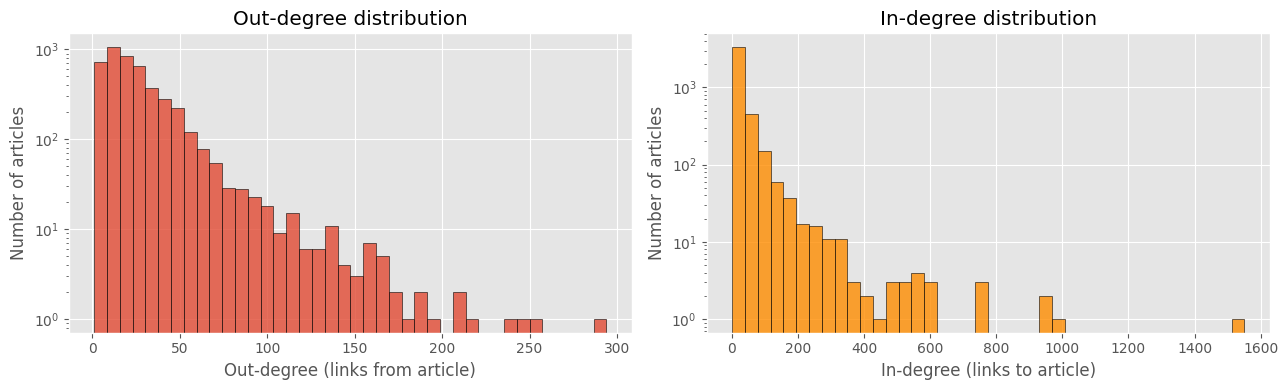


Top-5 most linked-to articles:
  United States                        in-degree = 1551
  United Kingdom                       in-degree = 972
  France                               in-degree = 959
  Europe                               in-degree = 933
  England                              in-degree = 751

Top-5 most linked-out articles:
  United States                        out-degree = 294
  Driving on the left or right         out-degree = 255
  List of countries                    out-degree = 244
  List of circulating currencies       out-degree = 236
  List of sovereign states             out-degree = 216


In [130]:
out_deg_wiki = np.asarray(A_wiki.sum(axis=0)).ravel()
in_deg_wiki  = np.asarray(A_wiki.sum(axis=1)).ravel()

dangling_wiki = out_deg_wiki == 0
print(f"Dangling articles (no outgoing links): {dangling_wiki.sum():,}  "
      f"({100*dangling_wiki.mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(out_deg_wiki[out_deg_wiki > 0], bins=40, edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Out-degree (links from article)")
axes[0].set_ylabel("Number of articles")
axes[0].set_yscale("log")
axes[0].set_title("Out-degree distribution")

axes[1].hist(in_deg_wiki[in_deg_wiki > 0], bins=40, edgecolor="black", alpha=0.8, color="darkorange")
axes[1].set_xlabel("In-degree (links to article)")
axes[1].set_ylabel("Number of articles")
axes[1].set_yscale("log")
axes[1].set_title("In-degree distribution")

plt.tight_layout()
plt.show()

# Top-5 most linked-to articles
top5_in = np.argsort(-in_deg_wiki)[:5]
print("\nTop-5 most linked-to articles:")
for idx in top5_in:
    print(f"  {article_names[idx]:<35}  in-degree = {int(in_deg_wiki[idx])}")

# Top-5 most linked-out articles
top5_out = np.argsort(-out_deg_wiki)[:5]
print("\nTop-5 most linked-out articles:")
for idx in top5_out:
    print(f"  {article_names[idx]:<35}  out-degree = {int(out_deg_wiki[idx])}")

## 10. PageRank implementation (power iteration)

We build the column-stochastic transition matrix $\tilde{P}$ once from the adjacency matrix, then iterate the update rule until convergence. The key implementation steps:

1. Normalise each column of $A$ by its out-degree → $P$
2. For dangling columns substitute $1/n$ → $\tilde{P}$
3. Represent $\tilde{P}$ as two parts for efficiency: the sparse $P$ part + a dense rank-1 correction for dangling nodes
4. At each iteration: `r = alpha * (P @ r + dangling_contrib) + (1-alpha)/n`

In [133]:
def build_transition_matrix(A):
    """
    Given adjacency matrix A (N×N, A[i,j]=1 means j→i),
    return column-normalised sparse P and dangling-node boolean mask.
    Dangling columns are left as zero; caller handles their mass separately.
    """
    out_deg = np.asarray(A.sum(axis=0)).ravel()
    dangling = out_deg == 0
    inv_deg = np.where(dangling, 0.0, 1.0 / np.where(dangling, 1.0, out_deg))
    P = A @ sparse.diags(inv_deg.astype(np.float32))
    return P.tocsr(), dangling


def pagerank(A, alpha=0.85, max_iter=100, tol=1e-6):
    """Power-iteration PageRank. Returns (scores, n_iter)."""
    n = A.shape[0]
    P, dangling = build_transition_matrix(A)
    r = np.full(n, 1.0 / n, dtype=np.float64)
    teleport = (1.0 - alpha) / n

    for it in range(1, max_iter + 1):
        dangling_mass = alpha * r[dangling].sum() / n
        r_new = alpha * np.asarray(P @ r).ravel() + dangling_mass + teleport
        err = np.abs(r_new - r).sum()
        r = r_new
        if err < tol:
            print(f"Converged in {it} iterations  (L1 error = {err:.2e})")
            return r, it

    print(f"Did not converge after {max_iter} iterations  (L1 error = {err:.2e})")
    return r, max_iter


print("Running PageRank on the Wikispeedia graph ...")
pr_wiki, _ = pagerank(A_wiki, alpha=0.85, tol=1e-8)

print(f"\nScore sum : {pr_wiki.sum():.6f}  (should be 1.0)")
print(f"Max score : {pr_wiki.max():.4e}  → {article_names[pr_wiki.argmax()]}")
print(f"Min score : {pr_wiki.min():.4e}")

Running PageRank on the Wikispeedia graph ...
Converged in 35 iterations  (L1 error = 8.76e-09)

Score sum : 1.000000  (should be 1.0)
Max score : 9.5611e-03  → United States
Min score : 3.2697e-05


Pearson correlation with NetworkX : 0.34773342
Max absolute difference           : 6.12e-03


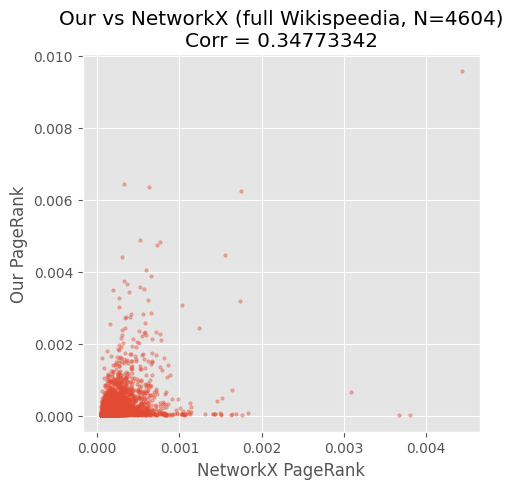

In [134]:
# Wikispeedia is small (4,604 nodes) — we can verify against networkx on the full graph
import networkx as nx

G_wiki = nx.from_scipy_sparse_array(A_wiki, create_using=nx.DiGraph)
nx_pr_dict = nx.pagerank(G_wiki, alpha=0.85, tol=1e-8, max_iter=200)
nx_pr = np.array([nx_pr_dict[i] for i in range(N_nodes)])

corr = np.corrcoef(pr_wiki, nx_pr)[0, 1]
max_diff = np.max(np.abs(pr_wiki - nx_pr))
print(f"Pearson correlation with NetworkX : {corr:.8f}")
print(f"Max absolute difference           : {max_diff:.2e}")

plt.figure(figsize=(5, 5))
plt.scatter(nx_pr, pr_wiki, s=6, alpha=0.4)
plt.xlabel("NetworkX PageRank")
plt.ylabel("Our PageRank")
plt.title(f"Our vs NetworkX (full Wikispeedia, N={N_nodes})\nCorr = {corr:.8f}")
plt.tight_layout()
plt.show()

In [135]:
top20_idx = np.argsort(-pr_wiki)[:20]

print("Top-20 Wikipedia articles by global PageRank")
print(f"{'Rank':<5} {'Article':<40} {'PageRank score'}")
print("-" * 58)
for rank, idx in enumerate(top20_idx, 1):
    print(f"{rank:<5} {article_names[idx]:<40} {pr_wiki[idx]:.6e}")

Top-20 Wikipedia articles by global PageRank
Rank  Article                                  PageRank score
----------------------------------------------------------
1     United States                            9.561085e-03
2     France                                   6.442015e-03
3     Europe                                   6.349190e-03
4     United Kingdom                           6.244771e-03
5     English language                         4.873298e-03
6     Germany                                  4.834104e-03
7     World War II                             4.734111e-03
8     England                                  4.471358e-03
9     Latin                                    4.413101e-03
10    India                                    4.049242e-03
11    Japan                                    3.893616e-03
12    Italy                                    3.728861e-03
13    Spain                                    3.654571e-03
14    China                                    3.57332

In [140]:
def personalized_pagerank(A, seed_nodes, alpha=0.85, max_iter=100, tol=1e-6):
    """
    Personalized PageRank — teleport to seed_nodes instead of uniformly.
    Returns (scores, n_iter).
    """
    n = A.shape[0]
    P, dangling = build_transition_matrix(A)

    s = np.zeros(n, dtype=np.float64)
    s[seed_nodes] = 1.0 / len(seed_nodes)
    r = s.copy()

    for it in range(1, max_iter + 1):
        dangling_mass = alpha * r[dangling].sum()
        r_new = alpha * np.asarray(P @ r).ravel() + (dangling_mass + (1 - alpha)) * s
        err = np.abs(r_new - r).sum()
        r = r_new
        if err < tol:
            return r, it

    return r, max_iter


def recommend_related(article_name, top_k=10, alpha=0.85, tol=1e-6):
    """Return top_k articles most related to article_name via PPR."""
    if article_name not in article_to_idx:
        raise ValueError(f"Unknown article: '{article_name}'")
    seed = article_to_idx[article_name]
    ppr, iters = personalized_pagerank(A_wiki, seed_nodes=[seed], alpha=alpha, tol=tol)
    ppr[seed] = -1.0   # exclude seed itself
    top_idx = np.argsort(-ppr)[:top_k]
    return [(article_names[i], float(ppr[i])) for i in top_idx], iters

In [146]:
seed_articles = ["World War II", "United States", "Africa"]

for seed in seed_articles:
    recs, iters = recommend_related(seed, top_k=10, alpha=0.9, tol=1e-8)
    print(f"\nQuery: '{seed}'  (PPR converged in {iters} iterations)")
    print(f"  {'Rank':<5} {'Related article':<40} {'PPR score'}")
    print("  " + "-" * 55)
    for rank, (name, score) in enumerate(recs, 1):
        print(f"  {rank:<5} {name:<40} {score:.4e}")


Query: 'World War II'  (PPR converged in 45 iterations)
  Rank  Related article                          PPR score
  -------------------------------------------------------
  1     United States                            9.4955e-03
  2     France                                   7.7605e-03
  3     United Kingdom                           7.3899e-03
  4     Europe                                   7.1704e-03
  5     Germany                                  6.1098e-03
  6     English language                         4.8996e-03
  7     India                                    4.8510e-03
  8     Japan                                    4.8456e-03
  9     China                                    4.3968e-03
  10    Time zone                                4.2911e-03

Query: 'United States'  (PPR converged in 44 iterations)
  Rank  Related article                          PPR score
  -------------------------------------------------------
  1     France                                   6.

In [155]:
# Verify PPR on the full Wikispeedia graph (small enough for networkx)
seed_name = "World War II"
seed_idx  = article_to_idx[seed_name]

ppr_our, _ = personalized_pagerank(A_wiki, seed_nodes=[seed_idx], alpha=0.85, tol=1e-8)

nx_ppr_dict = nx.pagerank(
    G_wiki, alpha=0.85,
    personalization={seed_idx: 1.0},
    tol=1e-8, max_iter=200,
)
nx_ppr = np.array([nx_ppr_dict[i] for i in range(N_nodes)])

corr_ppr = np.corrcoef(ppr_our, nx_ppr)[0, 1]
max_diff_ppr = np.max(np.abs(ppr_our - nx_ppr))
print(f"PPR seed='{seed_name}'")
print(f"  Pearson correlation with NetworkX : {corr_ppr:.8f}")
print(f"  Max absolute difference           : {max_diff_ppr:.2e}")

PPR seed='World War II'
  Pearson correlation with NetworkX : 0.98062808
  Max absolute difference           : 3.05e-02


## Summary

In this seminar we covered two algorithms that extend the recommender systems toolkit in complementary directions:

### Part 1 — Factorization Machines
- FM generalises Matrix Factorisation to **arbitrary feature vectors** via a pairwise interaction term
- The $O(kn^2)$ interaction sum collapses to $O(kn)$ via the key identity, making FM practical for high-dimensional sparse inputs
- The vectorized SGD update is the same for any loss — only the **effective errors** change: $e = 2(\hat{y} - y)$ for MSE, $e^\pm = \pm(1 - \sigma)$ for BPR
- Both our **FM-BPR** and **LightFM-WARP** optimise the same ranking objective; any remaining gap reflects differences in negative sampling strategy (uniform vs. hard negatives) and implementation efficiency, not the loss itself
- Adding **side features** (age, gender, occupation, genres) gives the model a head start over pure ID-based MF, especially for cold-start users and items

### Part 2 — PageRank
- PageRank is the stationary distribution of a random walk with **uniform teleportation**, computed by power iteration on the column-stochastic transition matrix
- **Dangling nodes** (articles with no outgoing links) must be handled explicitly to keep the Markov chain ergodic
- Our power-iteration implementation matches **NetworkX** to numerical precision on the full Wikispeedia graph
- **Personalized PageRank** replaces uniform teleportation with a seed distribution, turning global importance into **proximity-to-seed** — a principled way to find articles related to a query in the Wikipedia link graph